## Question 1

Download the binary file `corr.mat` and `mat2npy.py` from the course website and save them in the same folder. The file `mat2npy.py` is created from the `corr.mat` file.

In this question, perform a number of tests and then give your opinion, with reasons, as to whether the matrix is a valid correlation matrix.

**Setup**

Create a Python file `ex03q01.py`. The following imports may be needed:

```python
from numpy import maximum, finfo, all, flip, arange, count_nonzero, min, max, floor, log10, prod, diag, eye
from numpy.linalg import cond, eig
from scipy.linalg import cholesky, det, inv, LinAlgError
from matplotlib.pyplot import semilogy, title, grid
from mat2npy import K
```

**Tasks**

1. What are the dimensions of `K`? Is `K` square?
2. Is `K` symmetric?
3. Use the Cholesky factorisation

   $$
   K = R^T R
   $$

   to determine if `K` is positive definite.

4. Calculate and plot the eigenvalues of `K` in descending order. Then find the smallest and largest eigenvalues.
5. Calculate the determinant $\det(K)$ by:
   - using the function `scipy.linalg.det`;
   - using the Cholesky factorisation;
   - using the eigenvalues.

   Do all methods give the same answer?

6. Are all the diagonal entries of `K` equal to 1?
7. For different assets, find:
   - the minimum correlation;
   - the maximum correlation.
8. What percentage of the elements are nonzero?
9. An application supposedly requires the inverse $K^{-1}$. Calculate $K^{-1}$ using `scipy.linalg.inv`. Is `K` nonsingular? Does the inverse exist?
10. The application actually requires

    $$
    \alpha = b^T K^{-1} b.
    $$

    Answer:
    - Can this be done without using the inverse?
    - What is the most efficient way to calculate $\alpha$?

11. Calculate the condition number $\kappa_2(K)$ using the 2-norm.
    - If all data is known exactly, that is, to full double precision accuracy, how many significant figures are there in the solution to $Kx = b$?
12. Are there any other tests you could apply?
13. Is `K` a realistic correlation matrix?

K dim: 500x500, square=True
symmetric=True
positive definite
(d) Smallest eigenvalue = (2.818423244669015e-06+0j), largest eigenvalue = (45.71846627721324+0j)
0.0
0.0
0j
False
(f) all diagonal elements of K equal 1 to within 3.55e-15


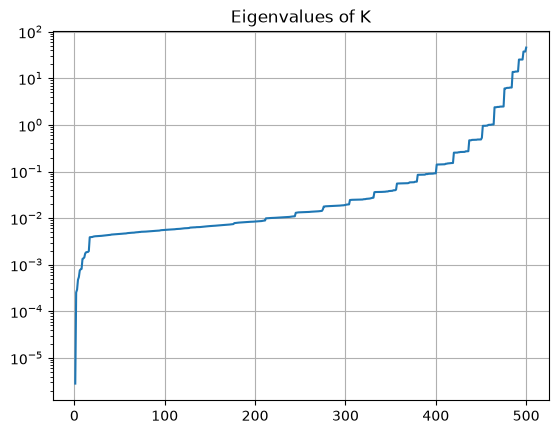

In [ ]:
from numpy import maximum, finfo, all, flip, arange, count_nonzero, min, max, floor, log10, prod, diag, eye
from numpy.linalg import cond, eig
from scipy.linalg import cholesky, det, inv, LinAlgError
from matplotlib.pyplot import semilogy, title, grid
from mat2npy import K

# a) dimensions of K and whether K is square
n, m = K.shape
print(f"K dim: {n}x{m}, square={n == m}")

# b) check whether K is symmetric
diff = abs(K - K.T) 
M =  maximum(K, K.T)
print(f"symmetric={all(diff <= finfo(float).eps * M)}")

# c) use Cholesky factorisation to test whether K is positive definite
try:
    R = cholesky(K)
    print("positive definite")
except: 
    print("not positive definite")

# d) calculate, sort, and plot eigenvalues of K; find smallest and largest eigenvalues
eigvals, eigvecs = eig(K)
eigvals.sort(descending=False)
semilogy(arange(1,n+1), eigvals)
title('Eigenvalues of K')
grid(True)
print(f'(d) Smallest eigenvalue = {eigvals.min()}, largest eigenvalue = {eigvals.max()}')

# e.i) calculate det(K) using scipy.linalg.det
d = det(K)

# e.ii) calculate det(K) using the Cholesky factorisation
# det(R) = product of r_{i,i} --> det(K) = det(R)^2
d_chol = prod(diag(R))**2

# e.iii) calculate det(K) using eigenvalues; compare all determinant methods
d_eig = prod(eigvals)
print(d)
print(d_chol)
print(d_eig)

# f) check whether all diagonal entries of K are equal to 1
print(all(diag(K) == 1))

d = diag(K)
worst = max(abs(d-1))
print(f'(f) all diagonal elements of K equal 1 to within {worst:0.2e}')

# g.i) find the minimum correlation between different assets


# g.ii) find the maximum correlation between different assets


# h) calculate the percentage of nonzero elements in K
# i) calculate inv(K); decide whether K is nonsingular and whether the inverse exists
# j.i) decide whether alpha = b.T @ inv(K) @ b can be calculated without forming inv(K)
# j.ii) find the most efficient way to calculate alpha
# k) calculate the 2-norm condition number kappa_2(K)
# k.i) estimate significant figures in the solution to Kx = b with full double precision data
# l) list any other useful tests for K
# m) decide whether K is a realistic correlation matrix

## Question 2

Download the Python function `laplace0.py` from the course website.

**Imports**

For the parts below, you need to import:

```python
from laplace0 import laplace0
from scipy.linalg import cholesky, norm, qr, eigvalsh, LinAlgError, svd, inv, lu
from scipy.sparse import eye
from numpy import prod
from matplotlib.pyplot import subplot, spy, figure, title, semilogy, grid
```

**Tasks**

1. What does this function do and what input arguments does it require?
2. Create a matrix `A` with `laplace0.py` using the default arguments.
3. Say as much as you can about the structure of `A`:
   - What are the dimensions of `A`?
   - Is `A` stored as a sparse matrix? Create a spy plot of `A`.
   - Is `A` symmetric, positive definite, or orthogonal?
   - Is `A` banded? What are the lower, upper, and total bandwidths of `A`?
   - Is `A` Toeplitz?
   - What are the eigenvalues of `A`? Plot them. Repeat for the singular values.
   - What is the determinant of `A`?
   - Does the inverse of `A` exist? What does a spy plot of the inverse tell you?
   - Calculate the LU, Cholesky, QR, spectral, and SVD factorisations of `A`.

In [ ]:
from laplace0 import laplace0
from scipy.linalg import cholesky, norm, qr, eigvalsh, LinAlgError, svd, inv, lu
from scipy.sparse import eye
from numpy import prod
from matplotlib.pyplot import subplot, spy, figure, title, semilogy, grid

# a) explain what laplace0 does and identify its input arguments
# b) create A using laplace0 with the default arguments
# c.i) find the dimensions of A
# c.ii) check whether A is sparse and create a spy plot of A
# c.iii) test whether A is symmetric, positive definite, and orthogonal
# c.iv) test whether A is banded and find lower, upper, and total bandwidths
# c.v) test whether A is Toeplitz
# c.vi) calculate and plot eigenvalues; calculate and plot singular values
# c.vii) calculate det(A)
# c.viii) check whether inv(A) exists and inspect a spy plot of inv(A)
# c.ix) calculate LU, Cholesky, QR, spectral, and SVD factorisations of A

## Question 3

### Part A

Write a Python function `matstruc(A, tol)` in a file script `matstrucpy.py` that returns a named tuple, say `s`, with information about the structure of the matrix `A`.

The fields of `s` should be as follows, using `tol` to define the tolerance used when deciding if a floating-point quantity is sufficiently close to zero.

**Starter code**

```python
from collections import namedtuple
from numpy import eye, count_nonzero, max, min
from scipy.linalg import norm, cholesky, toeplitz, tril, triu, LinAlgError, eigvals, svdvals
from scipy.sparse import csr_matrix, issparse

s = namedtuple(
    's',
    'dim1, dim2, square, maxval, minval, sym, posdef, orthog, bndup, bndlo, trilo, triup, toeplitz, evmin, evmax, svmin, svmax, cond, sparse, nnz, sparsity'
)

def matstruc(A, tol):
```

**Fields**

- `s.dim1` and `s.dim2` give the first and second dimensions of `A`, respectively.
- `s.square` is `True` if and only if `A` is a square matrix.
- `s.maxval` and `s.minval` are the maximum and minimum magnitudes of the entries of `A`.
- `s.sym` is `True` if `A` is symmetric.
- `s.posdef` is `True` if `A` is positive definite.
- `s.orthog` is `True` if `A` is orthogonal.
- `s.bndup` and `s.bndlo` are the upper and lower bandwidths of `A`.
- `s.trilo` is `True` if `A` is lower triangular.
- `s.triup` is `True` if `A` is upper triangular.
- `s.toeplitz` is `True` if `A` is Toeplitz.
- `s.evmin` and `s.evmax` give the smallest and largest eigenvalues in magnitude.
- `s.svmin` and `s.svmax` give the smallest and largest singular values.
- `s.cond` gives the condition number with respect to the 2-norm.

Test your function with the matrix

$$
A =
\begin{bmatrix}
2 & -1 & 0 & 0 \\
-1 & 2 & -1 & 0 \\
0 & -1 & 2 & -1 \\
0 & 0 & -1 & 2
\end{bmatrix}.
$$

### Part B

Modify your `matstruc` function so that it works when `A` is stored as a sparse matrix, and add the following fields:

- `s.sparse` is `True` if `A` is stored as a sparse matrix. Hint: `scipy.sparse.issparse`.
- `s.nnz` gives the number of nonzero elements in `A`.
- `s.sparsity` gives the percentage of zero elements in `A`.

Here, you need to import:

```python
from matstrucpy import matstruc
from numpy import array
from laplace0 import laplace0
```

Test your function with:

```python
A = laplace0()
```

In [ ]:
from collections import namedtuple
from numpy import eye, count_nonzero, max, min, array
from scipy.linalg import norm, cholesky, toeplitz, tril, triu, LinAlgError, eigvals, svdvals
from scipy.sparse import csr_matrix, issparse
from laplace0 import laplace0

s = namedtuple(
    's',
    'dim1, dim2, square, maxval, minval, sym, posdef, orthog, bndup, bndlo, trilo, triup, toeplitz, evmin, evmax, svmin, svmax, cond, sparse, nnz, sparsity'
)

# a) implement matstruc(A, tol) for dense matrices
# a) report dimensions, square status, max/min entry magnitudes, symmetry, positive definiteness, orthogonality
# a) report bandwidths, triangular structure, Toeplitz structure, eigenvalue/singular value ranges, and condition number
# a) test matstruc on the given 4-by-4 tridiagonal matrix
# b) modify matstruc so it also works for sparse matrices
# b) add sparse, nnz, and sparsity fields
# b) test matstruc with A = laplace0()